# Customer Churn — Telecom

## 1. Introduction

Customer churn is one of the main challenges faced by telecommunications companies. When customers leave, the company loses recurring revenue and must invest additional resources to acquire new customers.

This project analyzes customer data from a telecommunications company to identify the main patterns associated with customer churn and determine which customer segments present the highest risk of leaving.

The analysis will be developed using SQL and SQLite for data validation, preparation and analysis, followed by Power BI for interactive visualization.

### Project Approach

1. Data validation and quality assessment
2. Data preparation with SQL
3. Customer churn analysis
4. Identification of high-risk customer segments
5. Business recommendations
6. Power BI dashboard

### Main Business Question

> Which customer segments have the highest churn risk, and where should the company prioritize customer retention efforts?

### Tools

- SQL / SQLite
- VS Code
- Jupyter Notebook
- Power BI
- GitHub

## 2. Business Problem

For a telecommunications company, understanding why customers leave is essential for protecting recurring revenue and improving customer retention.

The objective of this analysis is to identify the customer characteristics and service combinations associated with higher churn rates.

Rather than analyzing churn only at an overall level, the project will compare customer segments based on contract type, tenure and Internet service.

The analysis will ultimately answer three key questions:

1. How large is the current churn problem?
2. Which customer segments have the highest churn rate?
3. Where should the company prioritize retention efforts?

In [3]:
import sqlite3

db_path = "../database/customer_churn.db"
conn = sqlite3.connect(db_path)

print("SQLite connection established.")

SQLite connection established.


## 3. Data Quality & Preparation

Before analyzing customer churn, the dataset was reviewed to identify missing values and duplicate customer records.

The dataset contains 7,043 customer records. Most fields are complete, but `TotalCharges` contains 11 missing values.

These records correspond to customers with a tenure of zero months. Since they have not generated any tenure-based charges, the missing values will be treated as zero in the analytical view without modifying the original dataset.

In [4]:
query = """
SELECT
    COUNT(*) AS total_records,
    SUM(CASE WHEN customerID IS NULL OR TRIM(customerID) = '' THEN 1 ELSE 0 END) AS customerID_missing,
    SUM(CASE WHEN tenure IS NULL THEN 1 ELSE 0 END) AS tenure_missing,
    SUM(CASE WHEN MonthlyCharges IS NULL THEN 1 ELSE 0 END) AS monthlycharges_missing,
    SUM(CASE WHEN TotalCharges IS NULL THEN 1 ELSE 0 END) AS totalcharges_missing,
    SUM(CASE WHEN Churn IS NULL OR TRIM(Churn) = '' THEN 1 ELSE 0 END) AS churn_missing
FROM customers;
"""

result = conn.execute(query)

for row in result:
    print(row)

(7043, 0, 0, 0, 11, 0)


In [5]:
query = """
SELECT
    customerID,
    COUNT(*) AS record_count
FROM customers
GROUP BY customerID
HAVING COUNT(*) > 1;
"""

result = conn.execute(query)

rows = result.fetchall()

print(f"Duplicate customers found: {len(rows)}")

Duplicate customers found: 0


## 4. Overall Customer Churn

The first step is to understand the overall magnitude of customer churn.

The analysis compares customers who stayed with those who left the company.

In [6]:
query = """
SELECT
    Churn,
    COUNT(*) AS total_customers,
    ROUND(
        100.0 * COUNT(*) / (SELECT COUNT(*) FROM customers),
        2
    ) AS percentage
FROM customers
GROUP BY Churn;
"""

result = conn.execute(query)

for row in result:
    print(row)

('No', 5174, 73.46)
('Yes', 1869, 26.54)


### Overall Churn Rate

The overall churn rate shows that more than one quarter of the customer base has left the company.

This provides a baseline for comparing churn across different customer segments.

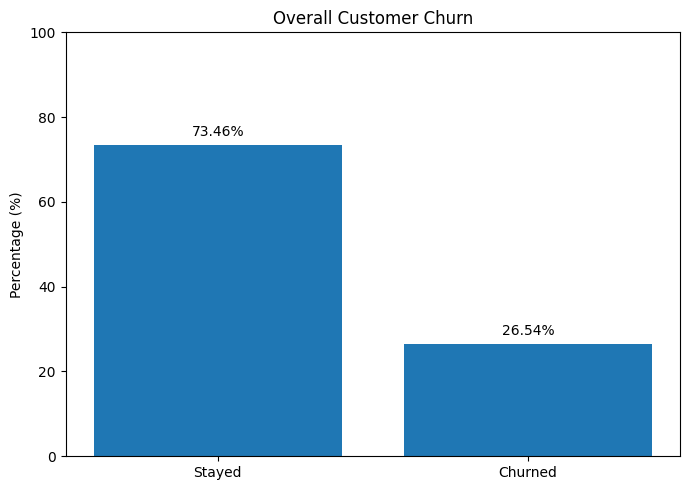

In [7]:
import matplotlib.pyplot as plt

query = """
SELECT
    Churn,
    COUNT(*) AS total_customers,
    ROUND(
        100.0 * COUNT(*) / (SELECT COUNT(*) FROM customers),
        2
    ) AS percentage
FROM customers
GROUP BY Churn;
"""

result = conn.execute(query).fetchall()

labels = [row[0] for row in result]
values = [row[2] for row in result]

labels = ["Stayed" if label == "No" else "Churned" for label in labels]

plt.figure(figsize=(7, 5))

bars = plt.bar(labels, values)

plt.title("Overall Customer Churn")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig("../images/churn_overall.png", dpi=300, bbox_inches="tight")

plt.show()

## 5. Churn by Contract

Contract type is an important factor in customer retention.

The analysis compares churn rates across month-to-month, one-year and two-year contracts.

In [8]:
query = """
SELECT
    Contract,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY Contract
ORDER BY churn_rate DESC;
"""

result = conn.execute(query)

for row in result:
    print(row)

('Month-to-month', 3875, 1655, 42.71)
('One year', 1473, 166, 11.27)
('Two year', 1695, 48, 2.83)


### Churn Rate by Contract

Customers with month-to-month contracts show a significantly higher churn rate than customers with longer-term contracts.

This suggests that contract duration is an important factor associated with customer retention.

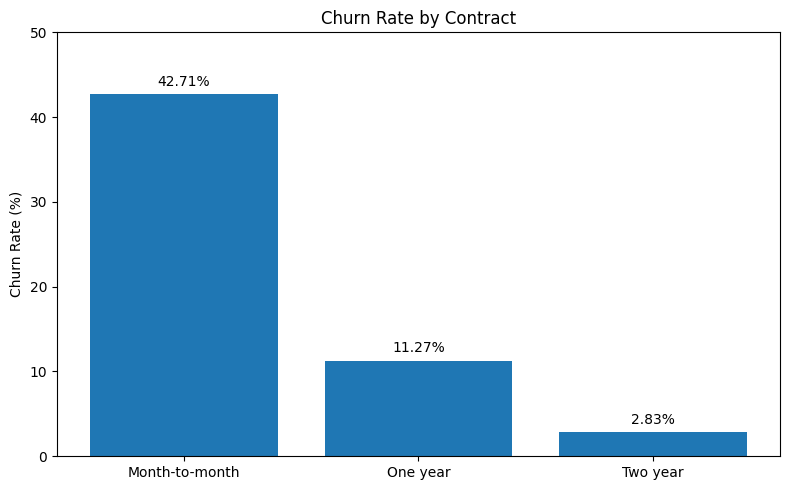

In [13]:
import matplotlib.pyplot as plt

query = """
SELECT
    Contract,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY Contract
ORDER BY churn_rate DESC;
"""

result = conn.execute(query).fetchall()

contracts = [row[0] for row in result]
churn_rates = [row[1] for row in result]

plt.figure(figsize=(8, 5))

bars = plt.bar(contracts, churn_rates)

plt.title("Churn Rate by Contract")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)

for bar, value in zip(bars, churn_rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig("../images/churn_by_contract.png", dpi=300, bbox_inches="tight")

plt.show()

## 6. Churn by Tenure

Customer tenure can indicate how customer retention changes over time.

Customers are grouped into four tenure ranges to identify whether churn is concentrated among newer or more established customers.

In [9]:
query = """
SELECT
    CASE
        WHEN tenure <= 12 THEN '0-12 months'
        WHEN tenure <= 24 THEN '13-24 months'
        WHEN tenure <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END AS tenure_group,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY tenure_group
ORDER BY
    CASE tenure_group
        WHEN '0-12 months' THEN 1
        WHEN '13-24 months' THEN 2
        WHEN '25-48 months' THEN 3
        ELSE 4
    END;
"""

result = conn.execute(query)

for row in result:
    print(row)

('0-12 months', 2186, 1037, 47.44)
('13-24 months', 1024, 294, 28.71)
('25-48 months', 1594, 325, 20.39)
('49+ months', 2239, 213, 9.51)


### Churn Rate by Customer Tenure

Churn is highest among customers during their first 12 months and decreases as customer tenure increases.

This indicates that the early stage of the customer relationship is a critical period for retention efforts.

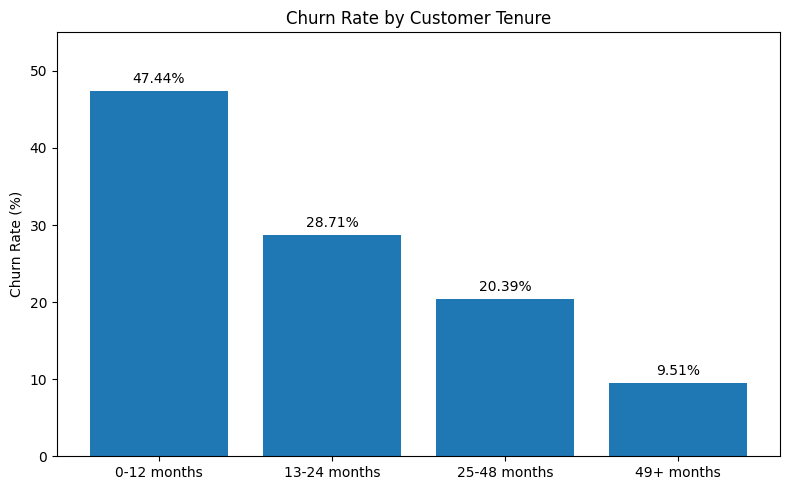

In [14]:
import matplotlib.pyplot as plt

query = """
SELECT
    CASE
        WHEN tenure <= 12 THEN '0-12 months'
        WHEN tenure <= 24 THEN '13-24 months'
        WHEN tenure <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END AS tenure_group,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY tenure_group
ORDER BY
    CASE tenure_group
        WHEN '0-12 months' THEN 1
        WHEN '13-24 months' THEN 2
        WHEN '25-48 months' THEN 3
        ELSE 4
    END;
"""

result = conn.execute(query).fetchall()

tenure_groups = [row[0] for row in result]
churn_rates = [row[1] for row in result]

plt.figure(figsize=(8, 5))

bars = plt.bar(tenure_groups, churn_rates)

plt.title("Churn Rate by Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 55)

for bar, value in zip(bars, churn_rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig("../images/churn_by_tenure.png", dpi=300, bbox_inches="tight")

plt.show()

## 7. High-Risk Segment: Contract and Tenure

The previous analyses showed that both month-to-month contracts and shorter customer tenure are associated with higher churn.

Combining these variables helps identify the customer segments with the greatest retention risk.

In [10]:
query = """
SELECT
    Contract,
    CASE
        WHEN tenure <= 12 THEN '0-12 months'
        WHEN tenure <= 24 THEN '13-24 months'
        WHEN tenure <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END AS tenure_group,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY Contract, tenure_group
ORDER BY churn_rate DESC;
"""

result = conn.execute(query)

for row in result:
    print(row)

('Month-to-month', '0-12 months', 1994, 1024, 51.35)
('Month-to-month', '13-24 months', 737, 278, 37.72)
('Month-to-month', '25-48 months', 802, 264, 32.92)
('Month-to-month', '49+ months', 342, 89, 26.02)
('One year', '49+ months', 634, 82, 12.93)
('One year', '25-48 months', 518, 55, 10.62)
('One year', '0-12 months', 124, 13, 10.48)
('One year', '13-24 months', 197, 16, 8.12)
('Two year', '49+ months', 1263, 42, 3.33)
('Two year', '25-48 months', 274, 6, 2.19)
('Two year', '0-12 months', 68, 0, 0.0)
('Two year', '13-24 months', 90, 0, 0.0)


### Churn Rate by Contract and Tenure

The combination of contract type and customer tenure reveals important differences in churn risk.

Month-to-month customers show consistently higher churn rates across all tenure groups, with the highest rate among customers with 0–12 months of tenure.

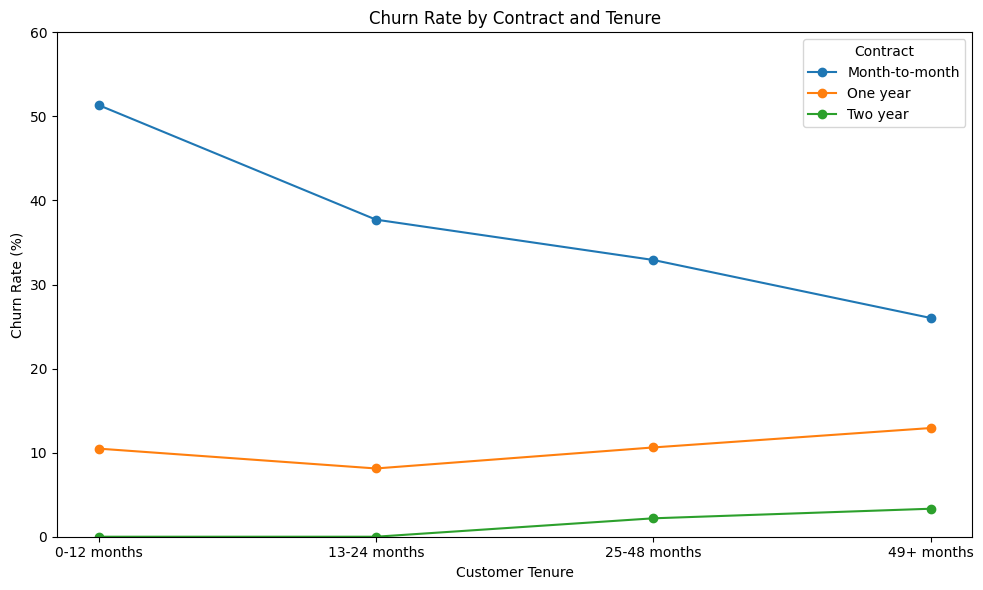

In [15]:
import matplotlib.pyplot as plt

query = """
SELECT
    Contract,
    CASE
        WHEN tenure <= 12 THEN '0-12 months'
        WHEN tenure <= 24 THEN '13-24 months'
        WHEN tenure <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END AS tenure_group,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY Contract, tenure_group
ORDER BY
    CASE tenure_group
        WHEN '0-12 months' THEN 1
        WHEN '13-24 months' THEN 2
        WHEN '25-48 months' THEN 3
        ELSE 4
    END;
"""

result = conn.execute(query).fetchall()

contracts = sorted(set(row[0] for row in result))
tenure_groups = [
    '0-12 months',
    '13-24 months',
    '25-48 months',
    '49+ months'
]

data = {}

for contract in contracts:
    data[contract] = []

    for tenure in tenure_groups:
        value = next(
            (
                row[2]
                for row in result
                if row[0] == contract and row[1] == tenure
            ),
            0
        )
        data[contract].append(value)

x = range(len(tenure_groups))

plt.figure(figsize=(10, 6))

for contract in contracts:
    plt.plot(x, data[contract], marker='o', label=contract)

plt.xticks(x, tenure_groups)
plt.title("Churn Rate by Contract and Tenure")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Customer Tenure")
plt.ylim(0, 60)
plt.legend(title="Contract")

plt.tight_layout()

plt.savefig(
    "../images/churn_contract_tenure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Churn by Internet Service

Internet service type may also influence customer retention.

The analysis compares churn rates across customers using fiber optic, DSL and customers without an Internet service.

In [11]:
query = """
SELECT
    InternetService,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY InternetService
ORDER BY churn_rate DESC;
"""

result = conn.execute(query)

for row in result:
    print(row)

('Fiber optic', 3096, 1297, 41.89)
('DSL', 2421, 459, 18.96)
('No', 1526, 113, 7.4)


### Churn Rate by Internet Service

Customers using fiber optic service have a substantially higher churn rate than customers using DSL or customers without Internet service.

This result indicates that Internet service type may be an important factor to consider when developing retention strategies.

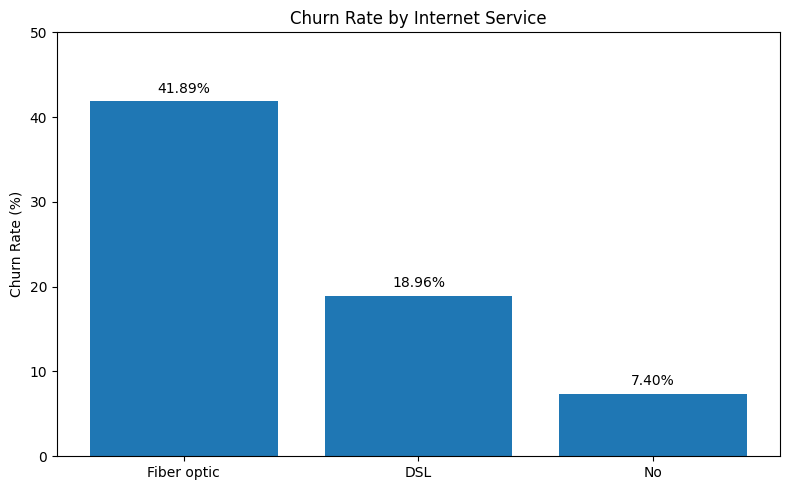

In [16]:
import matplotlib.pyplot as plt

query = """
SELECT
    InternetService,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY InternetService
ORDER BY churn_rate DESC;
"""

result = conn.execute(query).fetchall()

services = [row[0] for row in result]
churn_rates = [row[1] for row in result]

plt.figure(figsize=(8, 5))

bars = plt.bar(services, churn_rates)

plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)

for bar, value in zip(bars, churn_rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "../images/churn_by_internet_service.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. High-Risk Segment: Contract and Internet Service

The combination of contract type and Internet service provides a more detailed view of customer churn.

This analysis helps identify specific customer segments where retention efforts may have the greatest potential impact.

In [12]:
query = """
SELECT
    Contract,
    InternetService,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY Contract, InternetService
ORDER BY churn_rate DESC;
"""

result = conn.execute(query)

for row in result:
    print(row)

('Month-to-month', 'Fiber optic', 2128, 1162, 54.61)
('Month-to-month', 'DSL', 1223, 394, 32.22)
('One year', 'Fiber optic', 539, 104, 19.29)
('Month-to-month', 'No', 524, 99, 18.89)
('One year', 'DSL', 570, 53, 9.3)
('Two year', 'Fiber optic', 429, 31, 7.23)
('One year', 'No', 364, 9, 2.47)
('Two year', 'DSL', 628, 12, 1.91)
('Two year', 'No', 638, 5, 0.78)


### Churn Rate by Contract and Internet Service

The combination of contract type and Internet service reveals the customer segment with the highest observed churn rate.

Month-to-month customers with fiber optic service show the highest churn rate at 54.61%, making this segment a key priority for retention strategies.

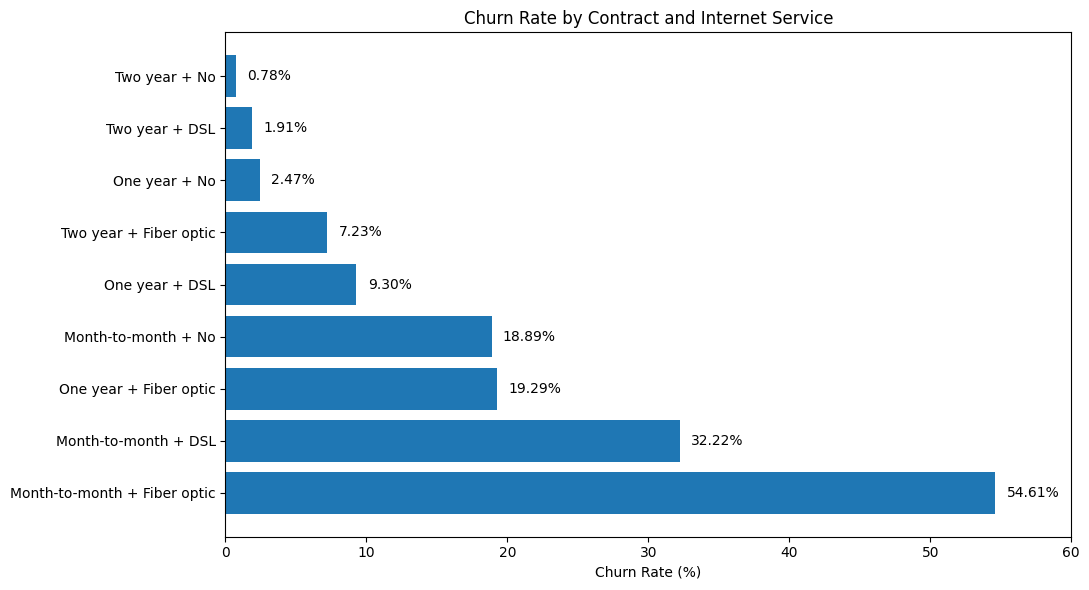

In [17]:
import matplotlib.pyplot as plt

query = """
SELECT
    Contract,
    InternetService,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY Contract, InternetService
ORDER BY churn_rate DESC;
"""

result = conn.execute(query).fetchall()

segments = [
    f"{row[0]} + {row[1]}"
    for row in result
]

churn_rates = [row[2] for row in result]

plt.figure(figsize=(11, 6))

bars = plt.barh(segments, churn_rates)

plt.title("Churn Rate by Contract and Internet Service")
plt.xlabel("Churn Rate (%)")
plt.xlim(0, 60)

for bar, value in zip(bars, churn_rates):
    plt.text(
        value + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "../images/churn_contract_internet.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Key Findings

The analysis identified several clear patterns associated with customer churn:

- The overall churn rate is **26.54%**.
- Month-to-month customers have a significantly higher churn rate (**42.71%**) than customers with one-year or two-year contracts.
- Customers with less than 12 months of tenure have the highest churn rate (**47.44%**).
- Fiber optic customers have a churn rate of **41.89%**.
- The highest-risk segment identified is customers with **month-to-month contracts and fiber optic service**, with a churn rate of **54.61%**.
- Customers with both short tenure and month-to-month contracts also show elevated churn, reaching **51.35%** among customers with 0–12 months of tenure.

These results suggest that churn is particularly concentrated among newer customers with flexible contracts and fiber optic service.

## 11. Business Recommendations

Based on the analysis, the company should prioritize retention strategies in the following areas:

1. **Early-stage customer retention**  
   Focus on customers during their first 12 months, when churn risk is highest.

2. **Month-to-month customers**  
   Encourage customers to transition to longer-term contracts through targeted offers and incentives.

3. **Fiber optic customers**  
   Investigate the reasons behind the high churn rate and evaluate service quality, pricing and customer experience.

4. **High-risk combinations**  
   Prioritize customers combining multiple risk factors, particularly month-to-month contracts and fiber optic service.

These actions can help the company focus retention resources on the customer segments with the highest observed churn rates.

## 12. Conclusion

Customer churn is not evenly distributed across the customer base.

The analysis shows that churn is strongly concentrated among specific customer segments, particularly newer customers, month-to-month contracts and fiber optic users.

The combination of **month-to-month contract and fiber optic service** represents the highest-risk segment identified, with a churn rate of **54.61%**.

These findings provide a clear starting point for targeted retention strategies and will be translated into an interactive Power BI dashboard to facilitate business monitoring and decision-making.